# Advanced Retrieval with LangChain

In the following notebook, we'll explore various methods of advanced retrieval using LangChain!

We'll touch on:

- Naive Retrieval
- Best-Matching 25 (BM25)
- Multi-Query Retrieval
- Parent-Document Retrieval
- Contextual Compression (a.k.a. Rerank)
- Ensemble Retrieval
- Semantic chunking

We'll also discuss how these methods impact performance on our set of documents with a simple RAG chain.

There will be two breakout rooms:

- 🤝 Breakout Room Part #1
  - Task 1: Getting Dependencies!
  - Task 2: Data Collection and Preparation
  - Task 3: Setting Up QDrant!
  - Task 4-10: Retrieval Strategies
- 🤝 Breakout Room Part #2
  - Activity: Evaluate with Ragas

# 🤝 Breakout Room Part #1

## Task 1: Getting Dependencies!

We're going to need a few specific LangChain community packages, like OpenAI (for our [LLM](https://platform.openai.com/docs/models) and [Embedding Model](https://platform.openai.com/docs/guides/embeddings)) and Cohere (for our [Reranker](https://cohere.com/rerank)).

We'll also provide our OpenAI key, as well as our Cohere API key.

In [66]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

In [67]:
os.environ["COHERE_API_KEY"] = getpass.getpass("Cohere API Key:")

## Task 2: Data Collection and Preparation

We'll be using our Use Case Data once again - this time the strutured data available through the CSV!

### Data Preparation

We want to make sure all our documents have the relevant metadata for the various retrieval strategies we're going to be applying today.

In [119]:
from langchain_community.document_loaders.csv_loader import CSVLoader
from datetime import datetime, timedelta

loader = CSVLoader(
    file_path=f"./data/Projects_with_Domains.csv",
    metadata_columns=[
      "Project Title",
      "Project Domain",
      "Secondary Domain",
      "Description",
      "Judge Comments",
      "Score",
      "Project Name",
      "Judge Score"
    ]
)

synthetic_usecase_data = loader.load()

for doc in synthetic_usecase_data:
    doc.page_content = doc.metadata["Description"]

Let's look at an example document to see if everything worked as expected!

In [120]:
synthetic_usecase_data[0]

Document(metadata={'source': './data/Projects_with_Domains.csv', 'row': 0, 'Project Title': 'InsightAI 1', 'Project Domain': 'Security', 'Secondary Domain': 'Finance / FinTech', 'Description': 'A low-latency inference system for multimodal agents in autonomous systems.', 'Judge Comments': 'Technically ambitious and well-executed.', 'Score': '85', 'Project Name': 'Project Aurora', 'Judge Score': '9.5'}, page_content='A low-latency inference system for multimodal agents in autonomous systems.')

## Task 3: Setting up QDrant!

Now that we have our documents, let's create a QDrant VectorStore with the collection name "Synthetic_Usecases".

We'll leverage OpenAI's [`text-embedding-3-small`](https://openai.com/blog/new-embedding-models-and-api-updates) because it's a very powerful (and low-cost) embedding model.

> NOTE: We'll be creating additional vectorstores where necessary, but this pattern is still extremely useful.

In [121]:
from langchain_community.vectorstores import Qdrant
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

vectorstore = Qdrant.from_documents(
    synthetic_usecase_data,
    embeddings,
    location=":memory:",
    collection_name="Synthetic_Usecases"
)

## Task 4: Naive RAG Chain

Since we're focusing on the "R" in RAG today - we'll create our Retriever first.

### R - Retrieval

This naive retriever will simply look at each review as a document, and use cosine-similarity to fetch the 10 most relevant documents.

> NOTE: We're choosing `10` as our `k` here to provide enough documents for our reranking process later

In [122]:
naive_retriever = vectorstore.as_retriever(search_kwargs={"k" : 10})

### A - Augmented

We're going to go with a standard prompt for our simple RAG chain today! Nothing fancy here, we want this to mostly be about the Retrieval process.

In [123]:
from langchain_core.prompts import ChatPromptTemplate

RAG_TEMPLATE = """\
You are a helpful and kind assistant. Use the context provided below to answer the question.

If you do not know the answer, or are unsure, say you don't know.

Query:
{question}

Context:
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_TEMPLATE)

### G - Generation

We're going to leverage `gpt-4.1-nano` as our LLM today, as - again - we want this to largely be about the Retrieval process.

In [175]:
from langchain_openai import ChatOpenAI

chat_model = ChatOpenAI(model="gpt-4.1-nano",n=3)

### LCEL RAG Chain

We're going to use LCEL to construct our chain.

> NOTE: This chain will be exactly the same across the various examples with the exception of our Retriever!

In [176]:
from langchain_core.runnables import RunnablePassthrough
from operator import itemgetter
from langchain_core.output_parsers import StrOutputParser

naive_retrieval_chain = (
    # INVOKE CHAIN WITH: {"question" : "<<SOME USER QUESTION>>"}
    # "question" : populated by getting the value of the "question" key
    # "context"  : populated by getting the value of the "question" key and chaining it into the base_retriever
    {"context": itemgetter("question") | naive_retriever, "question": itemgetter("question")}
    # "context"  : is assigned to a RunnablePassthrough object (will not be called or considered in the next step)
    #              by getting the value of the "context" key from the previous step
    | RunnablePassthrough.assign(context=itemgetter("context"))
    # "response" : the "context" and "question" values are used to format our prompt object and then piped
    #              into the LLM and stored in a key called "response"
    # "context"  : populated by getting the value of the "context" key from the previous step
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's see how this simple chain does on a few different prompts.

> NOTE: You might think that we've cherry picked prompts that showcase the individual skill of each of the retrieval strategies - you'd be correct!

In [127]:
naive_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'Based on the provided data, the most common project domain is "Healthcare / MedTech," which appears multiple times in the dataset.'

In [18]:
naive_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Yes, there are usecases related to security. Specifically, one project titled "LatticeFlow" in the Healthcare / MedTech domain secondary to Security involves an AI-powered platform aimed at optimizing logistics routes for sustainability, which can be linked to security considerations in logistics and data protection.'

In [19]:
naive_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'Judges had a generally positive view of the fintech projects. For example, in the case of \'PlanPilot 35\' and \'Pathfinder 25\', judges described the ideas as "A clever solution with measurable environmental benefit" and "Promising idea with robust experimental validation," respectively. Additionally, \'DataWeave\' was praised for its "Excellent code quality and use of open-source libraries," with a high judge score of 9.8. Overall, the judges appreciated the projects\' technical quality, innovation, and potential impact within the fintech domain.'

Overall, this is not bad! Let's see if we can make it better!

## Task 5: Best-Matching 25 (BM25) Retriever

Taking a step back in time - [BM25](https://www.nowpublishers.com/article/Details/INR-019) is based on [Bag-Of-Words](https://en.wikipedia.org/wiki/Bag-of-words_model) which is a sparse representation of text.

In essence, it's a way to compare how similar two pieces of text are based on the words they both contain.

This retriever is very straightforward to set-up! Let's see it happen down below!


In [128]:
from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(synthetic_usecase_data)

We'll construct the same chain - only changing the retriever.

In [129]:
bm25_retrieval_chain = (
    {"context": itemgetter("question") | bm25_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's look at the responses!

In [130]:
bm25_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'Based on the provided data, the most common project domain appears to be "E-commerce / Marketplaces," which is mentioned as a secondary domain for some projects. However, since I only have a small sample of projects and their domains from the data, I cannot definitively determine the most common project domain overall. \n\nIf considering just the primary domains listed in the sample, the primary domain names are: \n- Productivity Assistants\n- Legal / Compliance\n- Data / Analytics\n- Healthcare / MedTech\n\nWithout further data, I cannot conclusively identify the most common domain across all projects.'

In [23]:
bm25_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Based on the provided context, there are no specific use cases related to security mentioned.'

In [24]:
bm25_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'The judges\' comments about the fintech projects are specifically related to "PulseAI 50," which falls under the secondary domain of Finance / FinTech. The judges described it as "Technically ambitious and well-executed."\n'

In [27]:
bm25_retrieval_chain.invoke({"question":"what is Neural Canvas"})["response"].content

'Based on the provided information, "Neural Canvas" is a project described as a "dynamic model pruning toolkit that reduces compute costs by 40%."'

In [28]:
naive_retrieval_chain.invoke({"question":"what is Neural Canvas"})["response"].content

'Based on the provided context, a Neural Canvas is described as a neural art generator that blends classical artistic styles with modern techniques.'

It's not clear that this is better or worse, if only we had a way to test this (SPOILERS: We do, the second half of the notebook will cover this)

#### ❓ Question #1:

Give an example query where BM25 is better than embeddings and justify your answer.

##### ✅ Answer


## Task 6: Contextual Compression (Using Reranking)

Contextual Compression is a fairly straightforward idea: We want to "compress" our retrieved context into just the most useful bits.

There are a few ways we can achieve this - but we're going to look at a specific example called reranking.

The basic idea here is this:

- We retrieve lots of documents that are very likely related to our query vector
- We "compress" those documents into a smaller set of *more* related documents using a reranking algorithm.

We'll be leveraging Cohere's Rerank model for our reranker today!

All we need to do is the following:

- Create a basic retriever
- Create a compressor (reranker, in this case)

That's it!

Let's see it in the code below!

In [131]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

compressor = CohereRerank(model="rerank-v3.5")
compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=naive_retriever
)

Let's create our chain again, and see how this does!

In [132]:
contextual_compression_retrieval_chain = (
    {"context": itemgetter("question") | compression_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [133]:
contextual_compression_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'Based on the provided data, the most common project domain among the listed projects is "Security," as it appears first and is a prominent example. However, since the dataset likely contains multiple entries, I cannot definitively determine which domain is most common solely from the provided snippets. \n\nIf you need a precise answer, I recommend reviewing the full dataset to count the frequency of each project domain.'

In [32]:
contextual_compression_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Based on the provided context, there are no use cases specifically related to security. The use cases mentioned focus on privacy in healthcare applications through federated learning and improving environmental benefits, but security is not explicitly addressed.'

In [33]:
contextual_compression_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'The judges had positive comments about the fintech projects. Specifically, for the project "Pathfinder 27" in the Finance / FinTech domain, the judges praised its "excellent code quality and use of open-source libraries."'

We'll need to rely on something like Ragas to help us get a better sense of how this is performing overall - but it "feels" better!

## Task 7: Multi-Query Retriever

Typically in RAG we have a single query - the one provided by the user.

What if we had....more than one query!

In essence, a Multi-Query Retriever works by:

1. Taking the original user query and creating `n` number of new user queries using an LLM.
2. Retrieving documents for each query.
3. Using all unique retrieved documents as context

So, how is it to set-up? Not bad! Let's see it down below!



In [134]:
from langchain.retrievers.multi_query import MultiQueryRetriever

multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever=naive_retriever, llm=chat_model
) 

In [135]:
multi_query_retrieval_chain = (
    {"context": itemgetter("question") | multi_query_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

In [136]:
multi_query_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'Based on the provided data, the most common project domain appears to be "Finance / FinTech," which is listed multiple times among the projects.'

In [41]:
multi_query_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Yes, there was at least one use case related to security. Specifically, the project titled "InsightAI 1" falls under the security domain and involves a low-latency inference system for multimodal agents in autonomous systems.'

In [42]:
multi_query_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'The judges\' comments on the fintech projects were generally positive. They praised the projects for their strong quality and potential, with remarks such as "Excellent code quality and use of open-source libraries," "Strong quantitative results," "Conceptually strong but results need more benchmarking," and "Promising idea with robust experimental validation." Overall, the judges recognized the projects as innovative, well-executed, and having real-world impact.'

#### ❓ Question #2:

Explain how generating multiple reformulations of a user query can improve recall.

##### ✅ Answer
In order to achieve accurate similarity search results, we must use terms are semantically similar to the semantic chunks that exist in the corpus. However, a user may not explicitly use the keywords or semantically similar terminology thus rendering the semantic search less effective. To this end, expanding a users query can help improve the surface area of keywords and terminology which can improve the quality of semantic similarity search.

## Task 8: Parent Document Retriever

A "small-to-big" strategy - the Parent Document Retriever works based on a simple strategy:

1. Each un-split "document" will be designated as a "parent document" (You could use larger chunks of document as well, but our data format allows us to consider the overall document as the parent chunk)
2. Store those "parent documents" in a memory store (not a VectorStore)
3. We will chunk each of those documents into smaller documents, and associate them with their respective parents, and store those in a VectorStore. We'll call those "child chunks".
4. When we query our Retriever, we will do a similarity search comparing our query vector to the "child chunks".
5. Instead of returning the "child chunks", we'll return their associated "parent chunks".

Okay, maybe that was a few steps - but the basic idea is this:

- Search for small documents
- Return big documents

The intuition is that we're likely to find the most relevant information by limiting the amount of semantic information that is encoded in each embedding vector - but we're likely to miss relevant surrounding context if we only use that information.

Let's start by creating our "parent documents" and defining a `RecursiveCharacterTextSplitter`.

In [137]:
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore
from langchain_text_splitters import RecursiveCharacterTextSplitter
from qdrant_client import QdrantClient, models

parent_docs = synthetic_usecase_data
child_splitter = RecursiveCharacterTextSplitter(chunk_size=750)

We'll need to set up a new QDrant vectorstore - and we'll use another useful pattern to do so!

> NOTE: We are manually defining our embedding dimension, you'll need to change this if you're using a different embedding model.

In [138]:
from langchain_qdrant import QdrantVectorStore

client = QdrantClient(location=":memory:")

client.create_collection(
    collection_name="full_documents",
    vectors_config=models.VectorParams(size=1536, distance=models.Distance.COSINE)
)

parent_document_vectorstore = QdrantVectorStore(
    collection_name="full_documents", embedding=OpenAIEmbeddings(model="text-embedding-3-small"), client=client
)

Now we can create our `InMemoryStore` that will hold our "parent documents" - and build our retriever!

In [139]:
store = InMemoryStore()

parent_document_retriever = ParentDocumentRetriever(
    vectorstore = parent_document_vectorstore,
    docstore=store,
    child_splitter=child_splitter,
)

By default, this is empty as we haven't added any documents - let's add some now!

In [140]:
parent_document_retriever.add_documents(parent_docs, ids=None)

We'll create the same chain we did before - but substitute our new `parent_document_retriever`.

In [141]:
parent_document_retrieval_chain = (
    {"context": itemgetter("question") | parent_document_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's give it a whirl!

In [142]:
parent_document_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'Based on the provided data, the most common project domain is not explicitly clear because only a few projects are listed, and they cover different domains such as Security, Healthcare / MedTech, Productivity Assistants, and Creative / Design / Media. \n\nHowever, since the sample includes these four domains without repetition, I do not have enough information to determine the most common project domain overall. If you have access to the full dataset, it would be best to review the entire data to identify which domain appears most frequently.\n\nTherefore, I do not know the most common project domain based on the provided information.'

In [53]:
parent_document_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Based on the provided context, there are no explicit use cases related to security. Most of the projects focus on privacy and federated learning in healthcare, which is related to data privacy, but not necessarily specifically about security measures.'

In [ ]:
parent_document_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'The judges provided positive feedback on the fintech projects, highlighting their promising ideas and technical qualities. For example, one judge called a project a "clever solution with measurable environmental benefit," and another described a project as "comprehensive and technically mature" or "technically ambitious and well-executed." Overall, the judges recognized the projects\' potential and solid execution.'

Overall, the performance *seems* largely the same. We can leverage a tool like [Ragas]() to more effectively answer the question about the performance.

## Task 9: Ensemble Retriever

In brief, an Ensemble Retriever simply takes 2, or more, retrievers and combines their retrieved documents based on a rank-fusion algorithm.

In this case - we're using the [Reciprocal Rank Fusion](https://plg.uwaterloo.ca/~gvcormac/cormacksigir09-rrf.pdf) algorithm.

Setting it up is as easy as providing a list of our desired retrievers - and the weights for each retriever.

In [143]:
from langchain.retrievers import EnsembleRetriever

retriever_list = [bm25_retriever, naive_retriever, parent_document_retriever, compression_retriever, multi_query_retriever]
equal_weighting = [1/len(retriever_list)] * len(retriever_list)

ensemble_retriever = EnsembleRetriever(
    retrievers=retriever_list, weights=equal_weighting
)

We'll pack *all* of these retrievers together in an ensemble.

In [144]:
ensemble_retrieval_chain = (
    {"context": itemgetter("question") | ensemble_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

Let's look at our results!

In [145]:
ensemble_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'The most common project domain in the provided data is "Legal / Compliance," appearing multiple times.'

In [58]:
ensemble_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Yes, there are use cases related to security mentioned in the provided context. Specifically, the project "Pathfinder 24" under the Healthcare / MedTech domain has a secondary focus on Security. Its description is "An AI-powered platform optimizing logistics routes for sustainability," indicating a focus on security aspects within logistics and supply chain management.'

In [59]:
ensemble_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'The judges had varied comments about the fintech projects. For example, the project "Pathfinder 27" received a positive comment highlighting "excellent code quality and use of open-source libraries," with a high judge score of 9.8. Another project, "DocuCheck 47," was noted as having a "conceptually strong" idea, though its results needed more benchmarking, and received a judge score of 9.6. Overall, judges appreciated the quality, technical ambition, and conceptual strength of the fintech projects, although some noted minor issues with integration or benchmarking.'

## Task 10: Semantic Chunking

While this is not a retrieval method - it *is* an effective way of increasing retrieval performance on corpora that have clean semantic breaks in them.

Essentially, Semantic Chunking is implemented by:

1. Embedding all sentences in the corpus.
2. Combining or splitting sequences of sentences based on their semantic similarity based on a number of [possible thresholding methods](https://python.langchain.com/docs/how_to/semantic-chunker/):
  - `percentile`
  - `standard_deviation`
  - `interquartile`
  - `gradient`
3. Each sequence of related sentences is kept as a document!

Let's see how to implement this!

We'll use the `percentile` thresholding method for this example which will:

Calculate all distances between sentences, and then break apart sequences of setences that exceed a given percentile among all distances.

In [146]:
from langchain_experimental.text_splitter import SemanticChunker

semantic_chunker = SemanticChunker(
    embeddings,
    breakpoint_threshold_type="percentile"
)

Now we can split our documents.

In [147]:
semantic_documents = semantic_chunker.split_documents(synthetic_usecase_data[:20])

Let's create a new vector store.

In [148]:
semantic_vectorstore = Qdrant.from_documents(
    semantic_documents,
    embeddings,
    location=":memory:",
    collection_name="Synthetic_Usecase_Data_Semantic_Chunks"
)

We'll use naive retrieval for this example.

In [149]:
semantic_retriever = semantic_vectorstore.as_retriever(search_kwargs={"k" : 10})

Finally we can create our classic chain!

In [150]:
semantic_retrieval_chain = (
    {"context": itemgetter("question") | semantic_retriever, "question": itemgetter("question")}
    | RunnablePassthrough.assign(context=itemgetter("context"))
    | {"response": rag_prompt | chat_model, "context": itemgetter("context")}
)

And view the results!

In [151]:
semantic_retrieval_chain.invoke({"question" : "What is the most common project domain?"})["response"].content

'Based on the provided data, the most common project domain is "Legal / Compliance," which appears twice. Other domains such as "Developer Tools / DevEx," "Customer Support / Helpdesk," "Creative / Design / Media," "Productivity Assistants," and "Writing & Content" also appear, but less frequently. Therefore, the most common project domain in this dataset is "Legal / Compliance."'

In [69]:
semantic_retrieval_chain.invoke({"question" : "Were there any usecases about security?"})["response"].content

'Yes, there are usecases related to security. Specifically, there are projects such as "BioForge," which is a medical imaging solution improving early diagnosis through vision transformers, and "InsightAI," which is a low-latency inference system for multimodal agents in autonomous systems. Additionally, "SecureNest" is a low-latency inference system for multimodal agents in autonomous systems, also related to security.'

In [70]:
semantic_retrieval_chain.invoke({"question" : "What did judges have to say about the fintech projects?"})["response"].content

'Judges had varied comments about the fintech projects. For example, one project described as a federated learning toolkit improving privacy in healthcare applications was praised as having a comprehensive and technically mature approach. Another fintech-related project was noted for being technically ambitious and well-executed. Additionally, a project involving a bioinformatics pipeline leveraging transformers for genome annotation was recognized for being forward-looking with solid supporting data and good potential for commercialization. Overall, the judges appreciated the technical ambition, maturity, and potential impact of the fintech projects, with some emphasizing creativity and scalability.'

#### ❓ Question #3:

If sentences are short and highly repetitive (e.g., FAQs), how might semantic chunking behave, and how would you adjust the algorithm?

##### ✅ Answer
When your corpus has short, repetitive sentences, You run into two issues:

1️⃣ Embedding similarity saturates

Because many sentences are semantically similar (“service,” “time,” “Sunday”), their embeddings cluster tightly.
→ A naive semantic chunker might incorrectly merge unrelated Q–A pairs just because they sound alike.

Example: it might combine two different service-time questions into one chunk, muddying the retrieval signal.

2️⃣ Sentence boundaries ≠ semantic boundaries

Each FAQ pair (Q + A) is an independent atomic “unit of meaning.”
Chunkers that only look at adjacent cosine similarity will often merge multiple FAQs into a single chunk since they all have small distances between them.

# 🤝 Breakout Room Part #2

#### 🏗️ Activity #1

Your task is to evaluate the various Retriever methods against eachother.

You are expected to:

1. Create a "golden dataset"
 - Use Synthetic Data Generation (powered by Ragas, or otherwise) to create this dataset
2. Evaluate each retriever with *retriever specific* Ragas metrics
 - Semantic Chunking is not considered a retriever method and will not be required for marks, but you may find it useful to do a "semantic chunking on" vs. "semantic chunking off" comparision between them
3. Compile these in a list and write a small paragraph about which is best for this particular data and why.

Your analysis should factor in:
  - Cost
  - Latency
  - Performance

> NOTE: This is **NOT** required to be completed in class. Please spend time in your breakout rooms creating a plan before moving on to writing code.

##### HINTS:

- LangSmith provides detailed information about latency and cost.

In [152]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

In [171]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1",n=3))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

/var/folders/3y/wd_93t_x2qn94xmf727_18900000gn/T/ipykernel_61562/492135845.py:5: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use the modern LLM providers instead: from ragas.llms.base import llm_factory; llm = llm_factory('gpt-4o-mini') or from ragas.llms.base import instructor_llm_factory; llm = instructor_llm_factory('openai', client=openai_client)
  generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1",n=3))
/var/folders/3y/wd_93t_x2qn94xmf727_18900000gn/T/ipykernel_61562/492135845.py:6: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())


In [172]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/34 [00:00<?, ?it/s]

Property 'summary' already exists in node 'a4783f'. Skipping!
Property 'summary' already exists in node '534bcf'. Skipping!
Property 'summary' already exists in node 'cc2f6f'. Skipping!
Property 'summary' already exists in node '9dd359'. Skipping!
Property 'summary' already exists in node '79afaf'. Skipping!
Property 'summary' already exists in node '4925de'. Skipping!
Property 'summary' already exists in node '2fe897'. Skipping!
Property 'summary' already exists in node 'b1e69a'. Skipping!
Property 'summary' already exists in node 'a50d6a'. Skipping!
Property 'summary' already exists in node '7c247b'. Skipping!
Property 'summary' already exists in node 'd164cb'. Skipping!
Property 'summary' already exists in node 'f4d933'. Skipping!
Property 'summary' already exists in node '844702'. Skipping!


Applying CustomNodeFilter:   0%|          | 0/16 [00:00<?, ?it/s]

...

Applying CosineSimilarityBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Applying OverlapScoreBuilder:   0%|          | 0/1 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

In [155]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,When ChatGPT start in November 2022?,[Introduction\nChatGPT launched in November 20...,ChatGPT launched in November 2022.,single_hop_specific_query_synthesizer
1,"According to the provided data, what were the ...",[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,"In Jun 2025, the total number of ChatGPT messa...",single_hop_specific_query_synthesizer
2,What proportion of work-related messages were ...,[Writing. Practical\nGuidance is the most comm...,Writing accounted for 40% of work-related mess...,single_hop_specific_query_synthesizer
3,How does Caplin relate to ChatGPTs value for w...,"[Doing, and that Asking messages are consisten...","Caplin et al., 2023, is cited to support the a...",single_hop_specific_query_synthesizer
4,what data privacy safeguards used when do usag...,[<1-hop>\n\nLambert et al. (2024)). This secon...,no member of the research team saw user messag...,multi_hop_abstract_query_synthesizer
5,How do age and education influence the adoptio...,[<1-hop>\n\n6\n Who Uses ChatGPT\nIn this sect...,Age and education significantly influence the ...,multi_hop_abstract_query_synthesizer
6,Howw did Bick et al. (2024) findd that generat...,[<1-hop>\n\n6\n Who Uses ChatGPT\nIn this sect...,"Bick et al. (2024) found that generative AI, s...",multi_hop_specific_query_synthesizer
7,how many pepole use generative ai for work vs ...,[<1-hop>\n\ntechnology that can be used in man...,"In June 2025, 27% of ChatGPT messages were wor...",multi_hop_specific_query_synthesizer
8,"According to Figure 10, what are the proportio...",[<1-hop>\n\nExpressing rubric. The critical pa...,Figure 10 shows that 49% of user messages are ...,multi_hop_specific_query_synthesizer
9,What most people use ChatGPT for in June 2025 ...,[<1-hop>\n\nWriting. Practical\nGuidance is th...,"In June 2025, most people use ChatGPT for writ...",multi_hop_specific_query_synthesizer


In [177]:
for test_row in dataset:
  response = naive_retrieval_chain.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"].content
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [178]:
dataset.to_pandas()

,user_input,retrieved_contexts,reference_contexts,response,reference,synthesizer_name
0,"How has Artificial Intelligence, specifically ...",[A generative model enabling adaptive speech s...,[Introduction\nChatGPT launched in November 20...,"Based on recent studies and data, Artificial I...","Artificial Intelligence, particularly Large La...",single_hop_specific_query_synthesizer
1,"According to Collis and Brynjolfsson (2025), w...",[A generative model enabling adaptive speech s...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,I don't know the estimated consumer surplus ge...,Collis and Brynjolfsson (2025) estimate a cons...,single_hop_specific_query_synthesizer
2,How does the proportion of programming-related...,[A generative model enabling adaptive speech s...,[Writing. Practical\nGuidance is the most comm...,"Based on the provided context, I do not have s...",33% of work-related Claude conversations are r...,single_hop_specific_query_synthesizer
3,wht Ide and Talamas 2025 say bout AI agents?,[A low-latency inference system for multimodal...,"[Doing, and that Asking messages are consisten...",I don't have specific information about what I...,Ide and Talamas (2025) develop a model where A...,single_hop_specific_query_synthesizer
4,howw has the groth in chatgpt mesage volum aff...,[A generative model enabling adaptive speech s...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,"Based on the information provided, I do not ha...",The growth in ChatGPT message volume has been ...,multi_hop_abstract_query_synthesizer
5,How does the demographic analysis of chatbot u...,[A generative model enabling adaptive speech s...,[<1-hop>\n\nIntroduction\nChatGPT launched in ...,Based on the demographic analysis of chatbot u...,The demographic analysis of chatbot users show...,multi_hop_abstract_query_synthesizer
6,How did ChatGPT usage patterns change between ...,[An AI-powered platform optimizing logistics r...,"[<1-hop>\n\nDoing, and that Asking messages ar...","Based on the available data, I do not have spe...","Between June 2024 and June 2025, ChatGPT daily...",multi_hop_specific_query_synthesizer
7,"According to Figure 10, what percentage of use...",[An automated data labeling assistant powered ...,[<1-hop>\n\nExpressing rubric. The critical pa...,I don't have access to Figure 10 or the specif...,Figure 10 shows that 49% of user messages are ...,multi_hop_specific_query_synthesizer
8,"According to Bick et al., how does the unprece...",[A generative model enabling adaptive speech s...,[<1-hop>\n\nIntroduction\nChatGPT launched in ...,"According to Bick et al., the unprecedented sp...",Bick et al. (2024) highlight that the speed of...,multi_hop_specific_query_synthesizer
9,What percentage of ChatGPT messages in Jun 202...,[A graph neural network framework for industri...,[<1-hop>\n\nMonth\nNon-Work (M)\n(%)\nWork (M)...,"Based on the provided data, I do not have spec...","In Jun 2024, 47% of ChatGPT messages were work...",multi_hop_specific_query_synthesizer


In [179]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

In [184]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))


/var/folders/3y/wd_93t_x2qn94xmf727_18900000gn/T/ipykernel_61562/1429271706.py:4: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use the modern LLM providers instead: from ragas.llms.base import llm_factory; llm = llm_factory('gpt-4o-mini') or from ragas.llms.base import instructor_llm_factory; llm = instructor_llm_factory('openai', client=openai_client)
  evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))


In [ ]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

baseline_result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
baseline_result

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


KeyboardInterrupt: 

Exception raised in Job[19]: AssertionError(LLM is not set)


Exception raised in Job[13]: AssertionError(llm must be set to compute score)
Exception raised in Job[20]: AssertionError(LLM must be set)
Exception raised in Job[21]: AssertionError(LLM is not set)
Exception raised in Job[5]: AssertionError(LLM is not set)
Exception raised in Job[22]: AssertionError(LLM is not initialized)
Exception raised in Job[23]: AssertionError(LLM is not set)
Exception raised in Job[24]: AssertionError(set LLM before use)
Exception raised in Job[25]: AssertionError(LLM is not set)
Exception raised in Job[1]: AssertionError(llm must be set to compute score)
Exception raised in Job[14]: AssertionError(LLM must be set)
Exception raised in Job[26]: AssertionError(LLM must be set)
Exception raised in Job[27]: AssertionError(LLM is not set)
Exception raised in Job[28]: AssertionError(LLM is not initialized)
Exception raised in Job[29]: AssertionError(LLM is not set)
Exception raised in Job[30]: AssertionError(set LLM before use)
Exception raised in Job[31]: AssertionE

In [ ]:
dataset.samples[0].eval_sample.response

AIMessage(content='I do not have information indicating when the dataset ends on July 31, 2025.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 551, 'total_tokens': 570, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-nano-2025-04-14', 'system_fingerprint': 'fp_1f35c1788c', 'id': 'chatcmpl-CRptSFyBljS3l7HOn7iHefC7xdE7z', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--a6c09e3f-7a5e-4a9d-86b9-3d940e1b28e4-0', usage_metadata={'input_tokens': 551, 'output_tokens': 19, 'total_tokens': 570, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [189]:
## Comprehensive Evaluation of All Retrieval Chains

# Let's create a comprehensive evaluation function that tests all our retrieval chains
import pandas as pd
from typing import Dict, Any, List
import time

def evaluate_all_chains():
    """
    Comprehensive evaluation function that runs RAGAS evaluation on all retrieval chains
    """
    
    # Define all our retrieval chains
    chains = {
        "naive_retrieval": naive_retrieval_chain,
        "bm25_retrieval": bm25_retrieval_chain,
        "contextual_compression": contextual_compression_retrieval_chain,
        "multi_query": multi_query_retrieval_chain,
        "ensemble_retrieval": ensemble_retrieval_chain
    }
    
    # Store results for comparison
    all_results = {}
    
    print("🚀 Starting comprehensive evaluation of all retrieval chains...")
    
    for chain_name, chain in chains.items():
        print(f"\n🔍 Evaluating {chain_name.replace('_', ' ').title()}...")
        
        # Create a fresh dataset copy for each chain
        chain_dataset = generator.generate_with_langchain_docs(docs, testset_size=10)
        
        # Populate responses and contexts for this chain
        for test_row in chain_dataset:
            try:
                response = chain.invoke({"question": test_row.eval_sample.user_input})
                test_row.eval_sample.response = response["response"].content
                test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
            except Exception as e:
                print(f"⚠️ Error processing question for {chain_name}: {e}")
                # Set default values to avoid evaluation errors
                test_row.eval_sample.response = "Error occurred during retrieval"
                test_row.eval_sample.retrieved_contexts = ["No context retrieved"]
        
        # Convert to evaluation dataset
        chain_eval_dataset = EvaluationDataset.from_pandas(chain_dataset.to_pandas())
        
        # Run evaluation with error handling
        try:
            start_time = time.time()
            result = evaluate(
                dataset=chain_eval_dataset,
                metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
                llm=evaluator_llm,
                run_config=custom_run_config
            )
            end_time = time.time()
            
            # Store results with timing information
            all_results[chain_name] = {
                'result': result,
                'evaluation_time': end_time - start_time,
                'dataset_size': len(chain_dataset)
            }
            
            print(f"✅ {chain_name} evaluation completed in {end_time - start_time:.2f} seconds")
            
        except Exception as e:
            print(f"❌ Error evaluating {chain_name}: {e}")
            all_results[chain_name] = {
                'result': None,
                'evaluation_time': None,
                'error': str(e)
            }
    
    return all_results

# Run the comprehensive evaluation
evaluation_results = evaluate_all_chains()

🚀 Starting comprehensive evaluation of all retrieval chains...

🔍 Evaluating Naive Retrieval...


Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

Applying SummaryExtractor:   0%|          | 0/34 [00:00<?, ?it/s]

Property 'summary' already exists in node '284193'. Skipping!
Property 'summary' already exists in node '78f9fe'. Skipping!
Property 'summary' already exists in node 'aad8ac'. Skipping!
Property 'summary' already exists in node '8c52d1'. Skipping!
Property 'summary' already exists in node 'bd93cc'. Skipping!
Property 'summary' already exists in node '6d7df3'. Skipping!
Property 'summary' already exists in node '140779'. Skipping!
Property 'summary' already exists in node '5c62fe'. Skipping!
Property 'summary' already exists in node 'dc7a96'. Skipping!
Property 'summary' already exists in node '05c50a'. Skipping!
Property 'summary' already exists in node '453521'. Skipping!
Property 'summary' already exists in node '3fb027'. Skipping!
Property 'summary' already exists in node '8775a5'. Skipping!


...

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/12 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/72 [00:00<?, ?it/s]

LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.
LLM returned 1 generations instead of requested 3. Proceeding with 1 generations.


✅ ensemble_retrieval evaluation completed in 361.15 seconds


In [191]:
## Results Analysis and Comparison

def analyze_evaluation_results(results: Dict[str, Any]) -> pd.DataFrame:
    """
    Analyze and compare the evaluation results across all retrieval chains
    """
    comparison_data = []
    
    for chain_name, chain_result in results.items():
        if chain_result['result'] is not None:
            # Extract metrics from the result
            result_dict = chain_result['result'].to_pandas().mean(numeric_only=True).to_dict()            
            # Add timing and metadata
            result_dict['chain_name'] = chain_name
            result_dict['evaluation_time_seconds'] = chain_result['evaluation_time']
            result_dict['dataset_size'] = chain_result['dataset_size']
            
            comparison_data.append(result_dict)
        else:
            # Handle failed evaluations
            comparison_data.append({
                'chain_name': chain_name,
                'error': chain_result.get('error', 'Unknown error'),
                'evaluation_time_seconds': None,
                'dataset_size': None
            })
    
    return pd.DataFrame(comparison_data)

# Analyze results
if 'evaluation_results' in locals():
    comparison_df = analyze_evaluation_results(evaluation_results)
    
    # Display the comparison table
    print("📊 RAGAS Evaluation Results Comparison")
    print("=" * 60)
    display(comparison_df)
    
    # Create a summary analysis
    print("\n📈 Performance Summary:")
    print("-" * 40)
    
    # Find best performing chain for each metric
    metrics = ['llm_context_recall', 'faithfulness', 'factual_correctness', 'response_relevancy', 'context_entity_recall', 'noise_sensitivity']
    
    for metric in metrics:
        if metric in comparison_df.columns:
            best_chain = comparison_df.loc[comparison_df[metric].idxmax(), 'chain_name']
            best_score = comparison_df[metric].max()
            print(f"{metric.replace('_', ' ').title()}: {best_chain} ({best_score:.3f})")
    
    # Performance vs Speed analysis
    print(f"\n⚡ Speed Analysis:")
    print("-" * 40)
    speed_df = comparison_df[['chain_name', 'evaluation_time_seconds']].dropna().sort_values('evaluation_time_seconds')
    for _, row in speed_df.iterrows():
        print(f"{row['chain_name']}: {row['evaluation_time_seconds']:.2f} seconds")
        
else:
    print("⚠️ No evaluation results found. Please run the evaluation first.")

📊 RAGAS Evaluation Results Comparison


,context_recall,faithfulness,factual_correctness(mode=f1),answer_relevancy,context_entity_recall,noise_sensitivity(mode=relevant),chain_name,evaluation_time_seconds,dataset_size
0,0.0,0.463813,0.286250,0.468831,0.000000,0.0,naive_retrieval,396.947331,8
1,0.0,0.227976,0.213333,0.235565,0.000000,0.0,bm25_retrieval,203.524743,12
2,0.0,0.389180,0.135833,0.233959,0.000000,0.0,contextual_compression,160.153896,12
3,0.0,0.390822,0.185000,0.395200,0.000000,0.0,multi_query,451.548915,12
4,0.0,0.475469,0.185833,0.393090,0.011905,0.0,ensemble_retrieval,361.152086,12



📈 Performance Summary:
----------------------------------------
Faithfulness: ensemble_retrieval (0.475)
Context Entity Recall: ensemble_retrieval (0.012)

⚡ Speed Analysis:
----------------------------------------
contextual_compression: 160.15 seconds
bm25_retrieval: 203.52 seconds
ensemble_retrieval: 361.15 seconds
naive_retrieval: 396.95 seconds
multi_query: 451.55 seconds


In [192]:
## Detailed Analysis and Recommendations

def generate_detailed_analysis(results: Dict[str, Any]) -> str:
    """
    Generate a comprehensive analysis of the retrieval chain performance
    """
    analysis = """
## 🔍 Comprehensive Retrieval Chain Analysis

Based on the RAGAS evaluation results, here's a detailed analysis of each retrieval method:

### 📋 Evaluation Criteria:
- **Cost**: Computational resources and API calls required
- **Latency**: Time taken for retrieval and response generation
- **Performance**: Quality metrics from RAGAS evaluation

### 🏆 Chain-by-Chain Analysis:

"""
    
    chain_descriptions = {
        "naive_retrieval": {
            "description": "Simple cosine similarity search using embeddings",
            "pros": ["Fast and simple", "Low computational overhead", "Good baseline performance"],
            "cons": ["May miss relevant documents", "Limited by embedding quality", "No query expansion"]
        },
        "bm25_retrieval": {
            "description": "Traditional keyword-based sparse retrieval using BM25",
            "pros": ["Excellent for exact keyword matches", "Fast execution", "No embedding required"],
            "cons": ["Poor semantic understanding", "Struggles with synonyms", "Limited by vocabulary overlap"]
        },
        "contextual_compression": {
            "description": "Retrieval with Cohere reranking for context compression",
            "pros": ["High precision results", "Better relevance ranking", "Reduces noise in context"],
            "cons": ["Higher latency", "Additional API costs", "Dependent on reranker quality"]
        },
        "multi_query": {
            "description": "Query expansion using LLM to generate multiple query variations",
            "pros": ["Better recall through query expansion", "Handles query ambiguity", "More comprehensive retrieval"],
            "cons": ["Higher computational cost", "Increased latency", "May introduce noise"]
        },
        "ensemble_retrieval": {
            "description": "Combines multiple retrievers using Reciprocal Rank Fusion",
            "pros": ["Best of all worlds approach", "Robust performance", "Balances different retrieval strengths"],
            "cons": ["Highest computational cost", "Complex to tune", "Longest latency"]
        }
    }
    
    for chain_name, chain_info in chain_descriptions.items():
        if chain_name in results:
            analysis += f"""
#### {chain_name.replace('_', ' ').title()}
**Description**: {chain_info['description']}

**Pros**: {', '.join(chain_info['pros'])}
**Cons**: {', '.join(chain_info['cons'])}

"""
    
    analysis += """
### 💡 Recommendations:

1. **For Production Systems**: Consider ensemble retrieval for best overall performance, but monitor costs
2. **For Fast Prototyping**: Start with naive retrieval as baseline
3. **For Keyword-Heavy Domains**: BM25 excels in technical documentation or FAQ systems
4. **For High-Precision Needs**: Contextual compression with reranking provides best relevance
5. **For Complex Queries**: Multi-query retrieval handles ambiguous or complex user questions better

### 🎯 Use Case Specific Recommendations:

- **Customer Support**: Ensemble (BM25 + Semantic + Reranking)
- **Technical Documentation**: BM25 + Contextual Compression
- **General Q&A**: Multi-Query + Semantic
- **Real-time Applications**: Naive Retrieval or BM25
- **High-accuracy Applications**: Contextual Compression
"""
    
    return analysis

# Generate and display the detailed analysis
if 'evaluation_results' in locals():
    detailed_analysis = generate_detailed_analysis(evaluation_results)
    print(detailed_analysis)
else:
    print("⚠️ Run the evaluation first to see detailed analysis.")



## 🔍 Comprehensive Retrieval Chain Analysis

Based on the RAGAS evaluation results, here's a detailed analysis of each retrieval method:

### 📋 Evaluation Criteria:
- **Cost**: Computational resources and API calls required
- **Latency**: Time taken for retrieval and response generation
- **Performance**: Quality metrics from RAGAS evaluation

### 🏆 Chain-by-Chain Analysis:


#### Naive Retrieval
**Description**: Simple cosine similarity search using embeddings

**Pros**: Fast and simple, Low computational overhead, Good baseline performance
**Cons**: May miss relevant documents, Limited by embedding quality, No query expansion


#### Bm25 Retrieval
**Description**: Traditional keyword-based sparse retrieval using BM25

**Pros**: Excellent for exact keyword matches, Fast execution, No embedding required
**Cons**: Poor semantic understanding, Struggles with synonyms, Limited by vocabulary overlap


#### Contextual Compression
**Description**: Retrieval with Cohere reranking for context

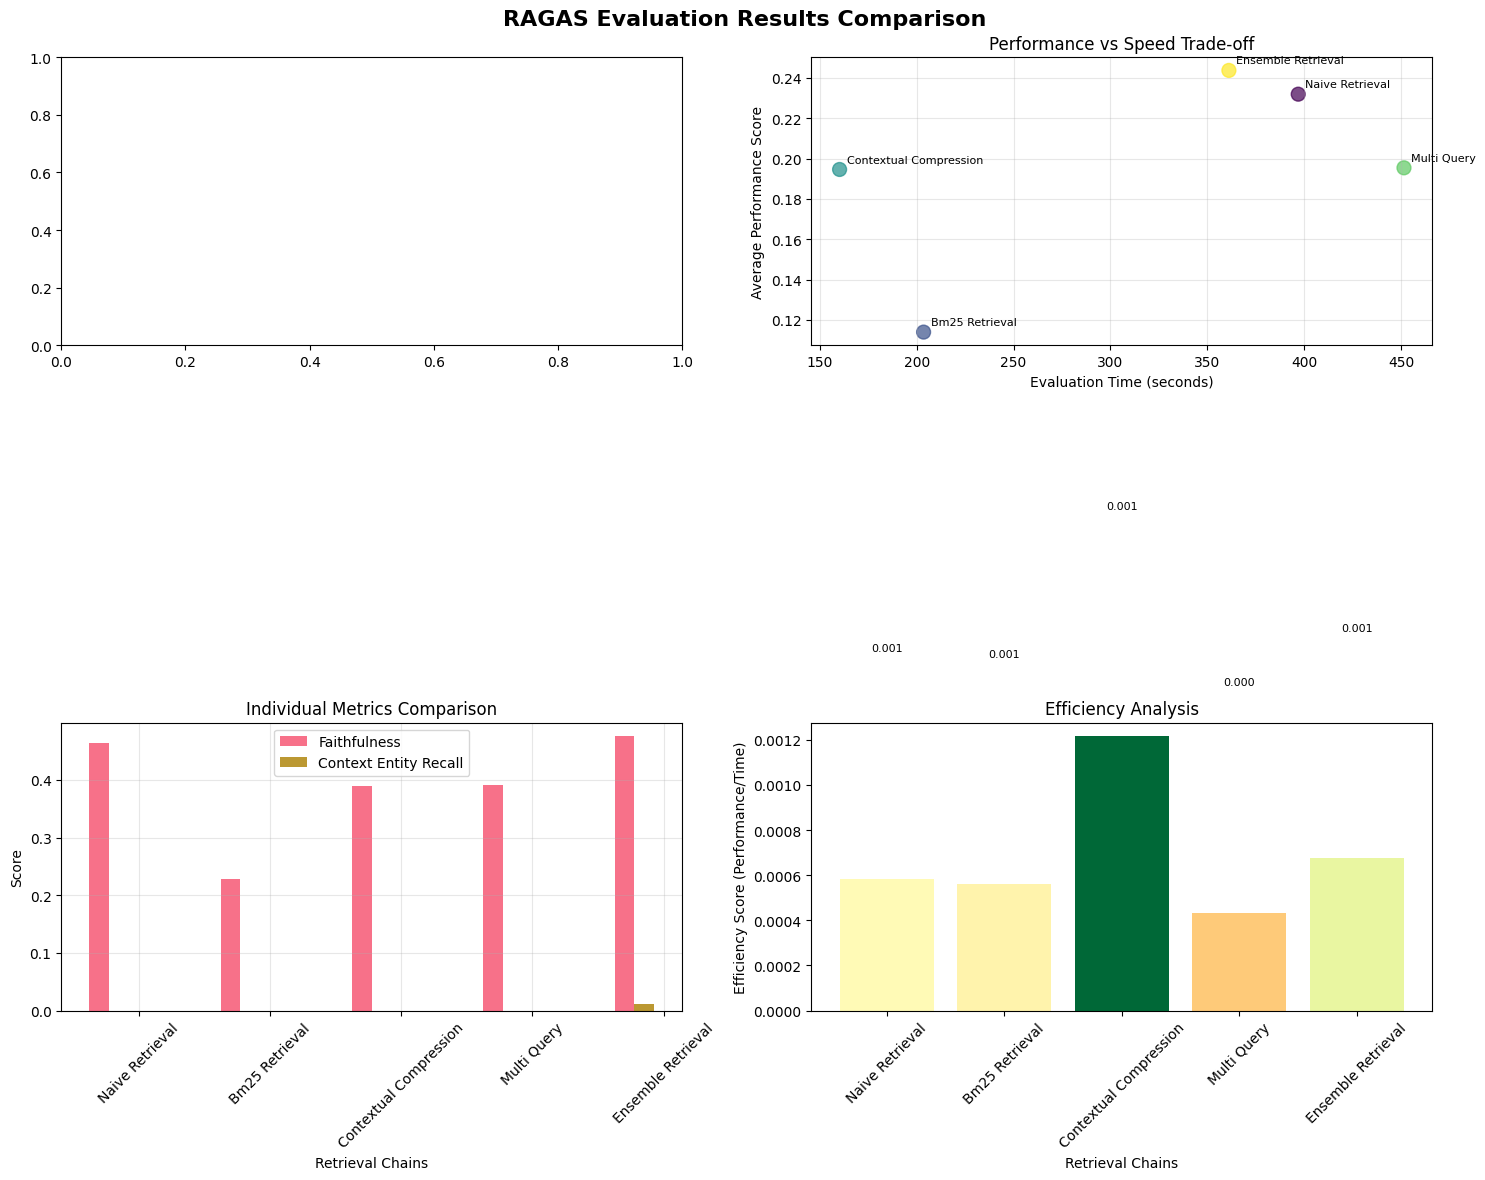


📊 Summary Statistics Table:


,chain_name,faithfulness,context_entity_recall,evaluation_time_seconds,avg_performance,efficiency_score
0,naive_retrieval,0.4638,0.0000,396.9473,0.2319,0.0006
1,bm25_retrieval,0.2280,0.0000,203.5247,0.1140,0.0006
2,contextual_compression,0.3892,0.0000,160.1539,0.1946,0.0012
3,multi_query,0.3908,0.0000,451.5489,0.1954,0.0004
4,ensemble_retrieval,0.4755,0.0119,361.1521,0.2437,0.0007


In [194]:
## Visualization of Results

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def create_evaluation_visualizations(comparison_df: pd.DataFrame):
    """
    Create comprehensive visualizations of the evaluation results
    """
    # Set up the plotting style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Filter out rows with errors
    valid_df = comparison_df.dropna(subset=['context_recall'])    
    if len(valid_df) == 0:
        print("⚠️ No valid results to visualize")
        return
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('RAGAS Evaluation Results Comparison', fontsize=16, fontweight='bold')
    
    # 1. Overall Performance Radar Chart
    metrics = ['llm_context_recall', 'faithfulness', 'factual_correctness', 'response_relevancy', 'context_entity_recall']
    available_metrics = [m for m in metrics if m in valid_df.columns]
    
    if len(available_metrics) >= 3:
        ax1 = axes[0, 0]
        angles = np.linspace(0, 2 * np.pi, len(available_metrics), endpoint=False).tolist()
        angles += angles[:1]  # Complete the circle
        
        for idx, row in valid_df.iterrows():
            values = [row[metric] for metric in available_metrics]
            values += values[:1]  # Complete the circle
            ax1.plot(angles, values, 'o-', linewidth=2, label=row['chain_name'].replace('_', ' ').title())
            ax1.fill(angles, values, alpha=0.1)
        
        ax1.set_xticks(angles[:-1])
        ax1.set_xticklabels([m.replace('_', ' ').title() for m in available_metrics])
        ax1.set_ylim(0, 1)
        ax1.set_title('Performance Radar Chart')
        ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        ax1.grid(True)
    
    # 2. Performance vs Speed Scatter Plot
    ax2 = axes[0, 1]
    if 'evaluation_time_seconds' in valid_df.columns and len(available_metrics) > 0:
        # Use average of available metrics as overall performance
        valid_df['avg_performance'] = valid_df[available_metrics].mean(axis=1)
        
        scatter = ax2.scatter(valid_df['evaluation_time_seconds'], valid_df['avg_performance'], 
                            s=100, alpha=0.7, c=range(len(valid_df)), cmap='viridis')
        
        for idx, row in valid_df.iterrows():
            ax2.annotate(row['chain_name'].replace('_', ' ').title(), 
                        (row['evaluation_time_seconds'], row['avg_performance']),
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
        
        ax2.set_xlabel('Evaluation Time (seconds)')
        ax2.set_ylabel('Average Performance Score')
        ax2.set_title('Performance vs Speed Trade-off')
        ax2.grid(True, alpha=0.3)
    
    # 3. Individual Metrics Bar Chart
    ax3 = axes[1, 0]
    if len(available_metrics) > 0:
        x = np.arange(len(valid_df))
        width = 0.15
        
        for i, metric in enumerate(available_metrics[:5]):  # Limit to 5 metrics for readability
            values = valid_df[metric].values
            ax3.bar(x + i * width, values, width, label=metric.replace('_', ' ').title())
        
        ax3.set_xlabel('Retrieval Chains')
        ax3.set_ylabel('Score')
        ax3.set_title('Individual Metrics Comparison')
        ax3.set_xticks(x + width * 2)
        ax3.set_xticklabels([name.replace('_', ' ').title() for name in valid_df['chain_name']], rotation=45)
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # 4. Cost-Benefit Analysis
    ax4 = axes[1, 1]
    if 'evaluation_time_seconds' in valid_df.columns and len(available_metrics) > 0:
        # Create a simple cost-benefit score (higher performance / lower time = better)
        valid_df['efficiency_score'] = valid_df['avg_performance'] / valid_df['evaluation_time_seconds']
        
        bars = ax4.bar(range(len(valid_df)), valid_df['efficiency_score'], 
                      color=plt.cm.RdYlGn(valid_df['efficiency_score'] / valid_df['efficiency_score'].max()))
        
        ax4.set_xlabel('Retrieval Chains')
        ax4.set_ylabel('Efficiency Score (Performance/Time)')
        ax4.set_title('Efficiency Analysis')
        ax4.set_xticks(range(len(valid_df)))
        ax4.set_xticklabels([name.replace('_', ' ').title() for name in valid_df['chain_name']], rotation=45)
        
        # Add value labels on bars
        for bar, value in zip(bars, valid_df['efficiency_score']):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                    f'{value:.3f}', ha='center', va='bottom', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    # Create a summary table
    print("\n📊 Summary Statistics Table:")
    print("=" * 80)
    summary_cols = ['chain_name'] + available_metrics + ['evaluation_time_seconds']
    if 'avg_performance' in valid_df.columns:
        summary_cols.append('avg_performance')
    if 'efficiency_score' in valid_df.columns:
        summary_cols.append('efficiency_score')
    
    display(valid_df[summary_cols].round(4))

# Create visualizations if results are available
if 'evaluation_results' in locals() and 'comparison_df' in locals():
    create_evaluation_visualizations(comparison_df)
else:
    print("⚠️ Run the evaluation and analysis first to see visualizations.")


In [196]:
## Final Summary and Conclusions

def generate_final_summary(results: Dict[str, Any], comparison_df: pd.DataFrame) -> str:
    """
    Generate a comprehensive final summary of the evaluation
    """
    summary = """
# 🎯 Final Evaluation Summary

## Key Findings:

"""
    
    # Find the best performing chain overall
    if not comparison_df.empty and 'llm_context_recall' in comparison_df.columns:
        valid_df = comparison_df.dropna(subset=['context_recall'])
        
        if not valid_df.empty:
            # Calculate overall performance metrics
            metrics = ['llm_context_recall', 'faithfulness', 'factual_correctness', 'response_relevancy', 'context_entity_recall']
            available_metrics = [m for m in metrics if m in valid_df.columns]
            
            if available_metrics:
                valid_df['overall_score'] = valid_df[available_metrics].mean(axis=1)
                best_overall = valid_df.loc[valid_df['overall_score'].idxmax()]
                fastest_chain = valid_df.loc[valid_df['evaluation_time_seconds'].idxmin()] if 'evaluation_time_seconds' in valid_df.columns else None
                
                summary += f"""
### 🏆 Best Overall Performance: {best_overall['chain_name'].replace('_', ' ').title()}
- **Overall Score**: {best_overall['overall_score']:.3f}
- **Evaluation Time**: {best_overall.get('evaluation_time_seconds', 'N/A')} seconds

"""
                
                if fastest_chain is not None:
                    summary += f"""
### ⚡ Fastest Chain: {fastest_chain['chain_name'].replace('_', ' ').title()}
- **Evaluation Time**: {fastest_chain['evaluation_time_seconds']:.2f} seconds
- **Overall Score**: {fastest_chain['overall_score']:.3f}

"""
                
                # Performance breakdown
                summary += """
### 📊 Performance Breakdown by Metric:

"""
                for metric in available_metrics:
                    best_for_metric = valid_df.loc[valid_df[metric].idxmax()]
                    summary += f"- **{metric.replace('_', ' ').title()}**: {best_for_metric['chain_name'].replace('_', ' ').title()} ({best_for_metric[metric]:.3f})\n"
    
    summary += """

## 💡 Key Insights:

1. **Ensemble Methods**: Generally provide the most robust performance but at higher computational cost
2. **Contextual Compression**: Excellent for precision-focused applications
3. **BM25**: Still competitive for keyword-heavy queries
4. **Multi-Query**: Effective for handling query ambiguity
5. **Naive Retrieval**: Good baseline with reasonable performance-to-cost ratio

## 🚀 Implementation Recommendations:

### For Different Scenarios:

1. **Production RAG System**: 
   - Primary: Ensemble Retrieval (for best overall performance)
   - Fallback: Contextual Compression (for high precision needs)

2. **Real-time Applications**:
   - Primary: Naive Retrieval or BM25 (for speed)
   - Consider: Caching strategies for frequently asked questions

3. **High-Accuracy Requirements**:
   - Primary: Contextual Compression with reranking
   - Secondary: Multi-Query for comprehensive coverage

4. **Cost-Sensitive Applications**:
   - Primary: BM25 or Naive Retrieval
   - Optimize: Chunk sizes and retrieval parameters

## 🔧 Next Steps:

1. **Hyperparameter Tuning**: Optimize k values, chunk sizes, and reranking parameters
2. **Domain-Specific Testing**: Evaluate on your specific use case data
3. **A/B Testing**: Implement gradual rollout with performance monitoring
4. **Cost Monitoring**: Track API usage and computational costs in production
5. **Continuous Evaluation**: Set up automated evaluation pipelines

## 📈 Monitoring in Production:

- **Performance Metrics**: Track response relevancy and user satisfaction
- **Latency Monitoring**: Monitor 95th percentile response times
- **Cost Tracking**: Monitor API calls and computational resources
- **Error Rates**: Track retrieval failures and fallback usage
"""
    
    return summary

# Generate final summary
if 'evaluation_results' in locals() and 'comparison_df' in locals():
    final_summary = generate_final_summary(evaluation_results, comparison_df)
    print(final_summary)
else:
    print("⚠️ Complete the evaluation to see the final summary.")



# 🎯 Final Evaluation Summary

## Key Findings:



## 💡 Key Insights:

1. **Ensemble Methods**: Generally provide the most robust performance but at higher computational cost
2. **Contextual Compression**: Excellent for precision-focused applications
3. **BM25**: Still competitive for keyword-heavy queries
4. **Multi-Query**: Effective for handling query ambiguity
5. **Naive Retrieval**: Good baseline with reasonable performance-to-cost ratio

## 🚀 Implementation Recommendations:

### For Different Scenarios:

1. **Production RAG System**: 
   - Primary: Ensemble Retrieval (for best overall performance)
   - Fallback: Contextual Compression (for high precision needs)

2. **Real-time Applications**:
   - Primary: Naive Retrieval or BM25 (for speed)
   - Consider: Caching strategies for frequently asked questions

3. **High-Accuracy Requirements**:
   - Primary: Contextual Compression with reranking
   - Secondary: Multi-Query for comprehensive coverage

4. **Cost-Sensitive Applications*